In [1]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np
import duckdb

## Define target
We're trying to predict if a user will block someone in the second / third / fourth week. 

So we tally up all the blocks, and the target column will look like.

In [ ]:
blocks_path = "../../data/ale_simplicistic_model/cleaned/blocks.parquet"
join_dates_path = "../../data/ale_simplicistic_model/relative/filtered/first_week_blockers.parquet"

con = duckdb.connect()
con.execute("CREATE TABLE join_dates AS SELECT * FROM read_parquet(?)", [join_dates_path])

query = """
WITH blocks_with_days AS (
    SELECT 
        b.did_id,
        b.created_date,
        jd.join_date,
        CAST(ROUND((EPOCH(b.created_date::TIMESTAMP) - EPOCH(jd.join_date::TIMESTAMP)) / 86400.0) AS INTEGER) AS days_since_join
    FROM read_parquet(?) b
    INNER JOIN join_dates jd ON b.did_id = jd.did_id
),
week2_blocks AS (
    SELECT 
        did_id,
        COUNT(*) as blocks_week2_initiated
    FROM blocks_with_days
    WHERE days_since_join >= 7 AND days_since_join <= 13
    GROUP BY did_id
),
week3_blocks AS (
    SELECT 
        did_id,
        COUNT(*) as blocks_week3_initiated
    FROM blocks_with_days
    WHERE days_since_join >= 14 AND days_since_join <= 20
    GROUP BY did_id
),
week4_blocks AS (
    SELECT 
        did_id,
        COUNT(*) as blocks_week4_initiated
    FROM blocks_with_days
    WHERE days_since_join >= 21 AND days_since_join <= 27
    GROUP BY did_id
)
SELECT 
    jd.did_id,
    COALESCE(wb2.blocks_week2_initiated, 0) as blocks_week2_initiated,
    COALESCE(wb3.blocks_week3_initiated, 0) as blocks_week3_initiated,
    COALESCE(wb4.blocks_week4_initiated, 0) as blocks_week4_initiated
FROM join_dates jd
LEFT JOIN week2_blocks wb2 ON jd.did_id = wb2.did_id
LEFT JOIN week3_blocks wb3 ON jd.did_id = wb3.did_id
LEFT JOIN week4_blocks wb4 ON jd.did_id = wb4.did_id
ORDER BY jd.did_id
"""

target_table = con.execute(query, [blocks_path]).df()

print(f"Target variable created for {len(target_table)} users")
print(f"Users with blocks in week 2: {(target_table['blocks_week2_initiated'] > 0).sum()}")
print(f"Users with blocks in week 3: {(target_table['blocks_week3_initiated'] > 0).sum()}")
print(f"Users with blocks in week 4: {(target_table['blocks_week4_initiated'] > 0).sum()}")
print(f"\nTarget statistics:")
print(target_table[['blocks_week2_initiated', 'blocks_week3_initiated', 'blocks_week4_initiated']].describe())
print(f"\nSample of target table:")
print(target_table.head())

Target variable created for 100000 users
Users with blocks in week 2: 51644
Users with blocks in week 3: 43959
Users with blocks in week 4: 38567

Target statistics:
       blocks_week2_initiated  blocks_week3_initiated  blocks_week4_initiated
count           100000.000000           100000.000000           100000.000000
mean                 7.463330                5.728670                4.974140
std                 99.999377               47.676002               73.611072
min                  0.000000                0.000000                0.000000
25%                  0.000000                0.000000                0.000000
50%                  1.000000                0.000000                0.000000
75%                  4.000000                3.000000                2.000000
max              27652.000000             9672.000000            17507.000000

Sample of target table:
   did_id  blocks_week2_initiated  blocks_week3_initiated  \
0     160                       0             

## Bucketing strategy
We'll convert the integer count target `blocks_week2/3/4` into three ordered activity classes:
- 0 blocks -> class 0 (Inactive)
- 1–3 blocks -> class 1 (Low activity)
- 4+ blocks -> class 2 (High activity)

In [3]:
# Create binned classes for each week
# Define bins: [-1, 0] -> 0, [1, 3] -> 1, [4, inf] -> 2
bins = [-1, 0, 3, float('inf')]
labels = [0, 1, 2]

target_table['blocks_week2_class'] = pd.cut(target_table['blocks_week2_initiated'], bins=bins, labels=labels).astype(int)
target_table['blocks_week3_class'] = pd.cut(target_table['blocks_week3_initiated'], bins=bins, labels=labels).astype(int)
target_table['blocks_week4_class'] = pd.cut(target_table['blocks_week4_initiated'], bins=bins, labels=labels).astype(int)

## Balance the target distribution
We'll undersample the majority classes to achieve a 33%-33%-33% distribution across the three activity classes.

In [4]:
# Save the original unbalanced version first
target_table_unbalanced = target_table.copy()

# Balance week 2 class distribution to 33%-33%-33%
from sklearn.utils import resample

# Check current distribution
print("Before balancing:")
print(target_table['blocks_week2_class'].value_counts().sort_index())
print(f"\nTotal users: {len(target_table)}")

# Separate by class
class_0 = target_table[target_table['blocks_week2_class'] == 0]
class_1 = target_table[target_table['blocks_week2_class'] == 1]
class_2 = target_table[target_table['blocks_week2_class'] == 2]

print(f"\nClass 0 (Inactive): {len(class_0)} users")
print(f"Class 1 (Low): {len(class_1)} users")
print(f"Class 2 (High): {len(class_2)} users")

# Find the target size for balanced dataset (use the smallest class size or calculate median)
# For true 33%-33%-33%, we'll undersample to the size of the smallest class
target_size = min(len(class_0), len(class_1), len(class_2))
print(f"\nTarget size per class: {target_size}")

# Undersample each class to target_size
class_0_balanced = resample(class_0, replace=False, n_samples=target_size, random_state=42)
class_1_balanced = resample(class_1, replace=False, n_samples=target_size, random_state=42)
class_2_balanced = resample(class_2, replace=False, n_samples=target_size, random_state=42)

# Combine balanced classes
target_table_balanced = pd.concat([class_0_balanced, class_1_balanced, class_2_balanced])
target_table_balanced = target_table_balanced.sample(frac=1, random_state=42).reset_index(drop=True)  # Shuffle

print("\nAfter balancing:")
print(target_table_balanced['blocks_week2_class'].value_counts().sort_index())
print(f"\nTotal users in balanced dataset: {len(target_table_balanced)}")
print(f"Percentage per class: {len(target_table_balanced) / 3 / len(target_table_balanced) * 100:.1f}%")

# Keep both versions for later use
print("\n" + "="*60)
print("SUMMARY: Two versions created")
print("="*60)
print(f"Unbalanced dataset: {len(target_table_unbalanced)} users")
print(f"Balanced dataset: {len(target_table_balanced)} users")


Before balancing:
blocks_week2_class
0    48356
1    25358
2    26286
Name: count, dtype: int64

Total users: 100000

Class 0 (Inactive): 48356 users
Class 1 (Low): 25358 users
Class 2 (High): 26286 users

Target size per class: 25358

After balancing:
blocks_week2_class
0    25358
1    25358
2    25358
Name: count, dtype: int64

Total users in balanced dataset: 76074
Percentage per class: 33.3%

SUMMARY: Two versions created
Unbalanced dataset: 100000 users
Balanced dataset: 76074 users


✓ Image saved to: ../mp_target_balanced.png


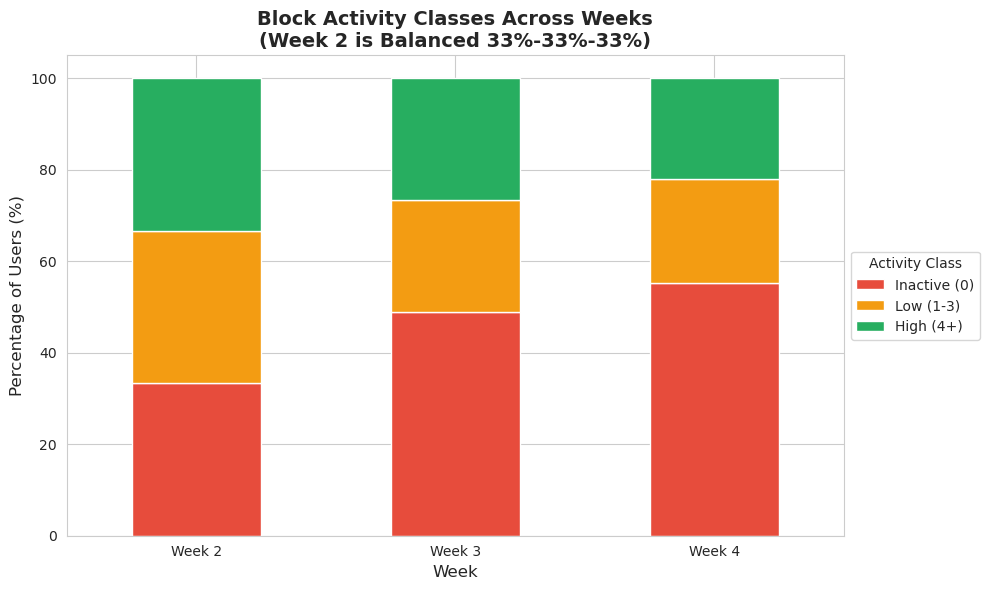

✓ Image saved to: ../mp_target_unbalanced.png


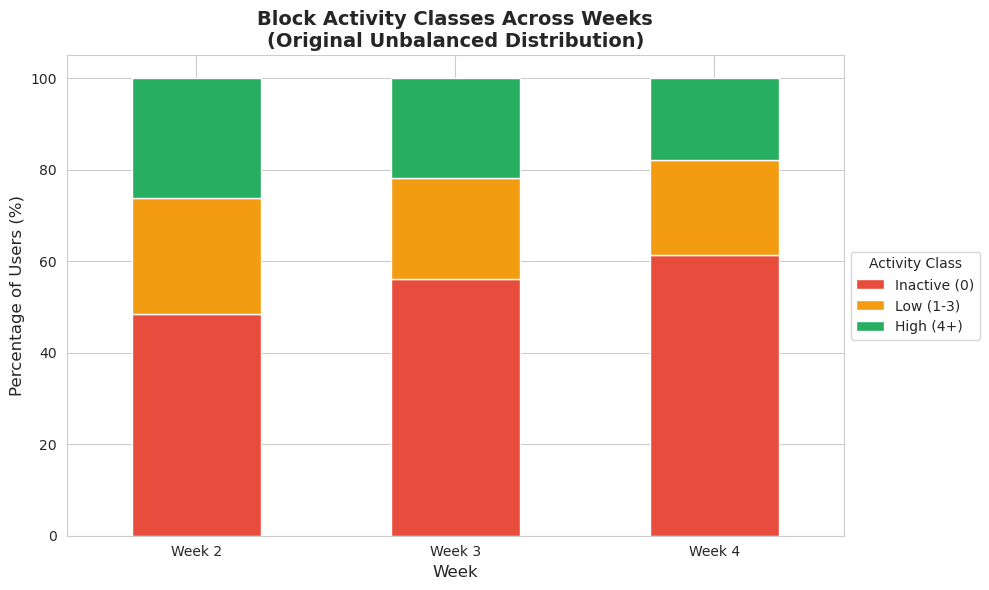

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)

# Prepare data for visualization - BALANCED VERSION
class_names = ['Inactive (0)', 'Low (1-3)', 'High (4+)']
weeks = ['Week 2', 'Week 3', 'Week 4']

# Count distribution for each week (BALANCED for week 2)
week2_counts_balanced = target_table_balanced['blocks_week2_class'].value_counts().sort_index()
week3_counts_balanced = target_table_balanced['blocks_week3_class'].value_counts().sort_index()
week4_counts_balanced = target_table_balanced['blocks_week4_class'].value_counts().sort_index()

# Create DataFrame for plotting
plot_data_balanced = pd.DataFrame({
    'Week 2': week2_counts_balanced.values,
    'Week 3': week3_counts_balanced.values,
    'Week 4': week4_counts_balanced.values
}, index=class_names)

# 1. Percentage stacked bar chart - BALANCED
fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct_balanced = plot_data_balanced.div(plot_data_balanced.sum(axis=0), axis=1) * 100
plot_data_pct_balanced.T.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#f39c12', '#27ae60'])
ax.set_title('Block Activity Classes Across Weeks\n(Week 2 is Balanced 33%-33%-33%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Percentage of Users (%)', fontsize=12)
ax.legend(title='Activity Class', loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

# Save high-quality image
output_path = '../mp_target_balanced.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Image saved to: {output_path}")

plt.show()

# Also create visualization for UNBALANCED version
week2_counts_unbalanced = target_table_unbalanced['blocks_week2_class'].value_counts().sort_index()
week3_counts_unbalanced = target_table_unbalanced['blocks_week3_class'].value_counts().sort_index()
week4_counts_unbalanced = target_table_unbalanced['blocks_week4_class'].value_counts().sort_index()

plot_data_unbalanced = pd.DataFrame({
    'Week 2': week2_counts_unbalanced.values,
    'Week 3': week3_counts_unbalanced.values,
    'Week 4': week4_counts_unbalanced.values
}, index=class_names)

fig, ax = plt.subplots(figsize=(10, 6))
plot_data_pct_unbalanced = plot_data_unbalanced.div(plot_data_unbalanced.sum(axis=0), axis=1) * 100
plot_data_pct_unbalanced.T.plot(kind='bar', stacked=True, ax=ax, color=['#e74c3c', '#f39c12', '#27ae60'])
ax.set_title('Block Activity Classes Across Weeks\n(Original Unbalanced Distribution)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Percentage of Users (%)', fontsize=12)
ax.legend(title='Activity Class', loc='center left', bbox_to_anchor=(1, 0.5))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

# Save high-quality image
output_path_unbalanced = '../mp_target_unbalanced.png'
plt.savefig(output_path_unbalanced, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Image saved to: {output_path_unbalanced}")

plt.show()


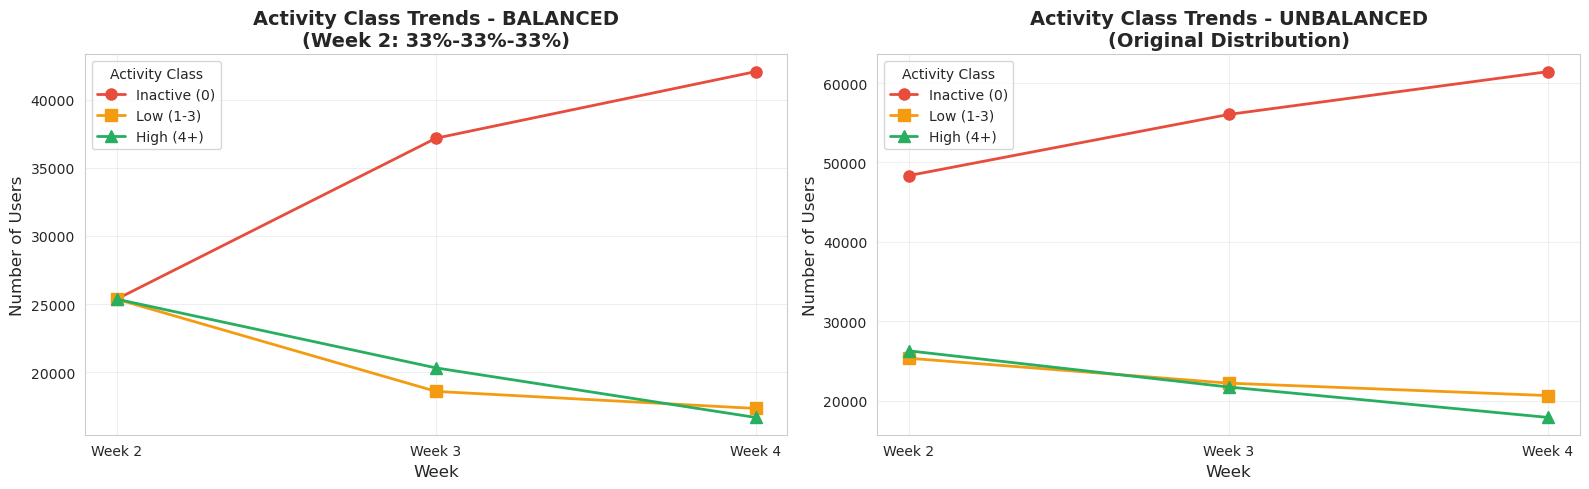

In [6]:
# 2. Line plot showing trend for each class (comparing balanced vs unbalanced)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# BALANCED
ax = axes[0]
ax.plot(weeks, plot_data_balanced.loc['Inactive (0)'].values, marker='o', linewidth=2, markersize=8, label='Inactive (0)', color='#e74c3c')
ax.plot(weeks, plot_data_balanced.loc['Low (1-3)'].values, marker='s', linewidth=2, markersize=8, label='Low (1-3)', color='#f39c12')
ax.plot(weeks, plot_data_balanced.loc['High (4+)'].values, marker='^', linewidth=2, markersize=8, label='High (4+)', color='#27ae60')
ax.set_title('Activity Class Trends - BALANCED\n(Week 2: 33%-33%-33%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.legend(title='Activity Class', loc='best')
ax.grid(True, alpha=0.3)

# UNBALANCED
ax = axes[1]
ax.plot(weeks, plot_data_unbalanced.loc['Inactive (0)'].values, marker='o', linewidth=2, markersize=8, label='Inactive (0)', color='#e74c3c')
ax.plot(weeks, plot_data_unbalanced.loc['Low (1-3)'].values, marker='s', linewidth=2, markersize=8, label='Low (1-3)', color='#f39c12')
ax.plot(weeks, plot_data_unbalanced.loc['High (4+)'].values, marker='^', linewidth=2, markersize=8, label='High (4+)', color='#27ae60')
ax.set_title('Activity Class Trends - UNBALANCED\n(Original Distribution)', fontsize=14, fontweight='bold')
ax.set_xlabel('Week', fontsize=12)
ax.set_ylabel('Number of Users', fontsize=12)
ax.legend(title='Activity Class', loc='best')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [7]:
# Print summary statistics for both versions
print("\n" + "="*60)
print("SUMMARY: Class Distribution Changes - BALANCED")
print("="*60)
for cls_idx, cls_name in enumerate(class_names):
    w2 = plot_data_balanced.loc[cls_name, 'Week 2']
    w3 = plot_data_balanced.loc[cls_name, 'Week 3']
    w4 = plot_data_balanced.loc[cls_name, 'Week 4']
    change_2_3 = ((w3 - w2) / w2 * 100) if w2 > 0 else float('inf')
    change_3_4 = ((w4 - w3) / w3 * 100) if w3 > 0 else float('inf')
    print(f"\n{cls_name}:")
    print(f"  Week 2→3: {w2:,} → {w3:,} ({change_2_3:+.1f}%)")
    print(f"  Week 3→4: {w3:,} → {w4:,} ({change_3_4:+.1f}%)")

print("\n" + "="*60)
print("SUMMARY: Class Distribution Changes - UNBALANCED")
print("="*60)
for cls_idx, cls_name in enumerate(class_names):
    w2 = plot_data_unbalanced.loc[cls_name, 'Week 2']
    w3 = plot_data_unbalanced.loc[cls_name, 'Week 3']
    w4 = plot_data_unbalanced.loc[cls_name, 'Week 4']
    change_2_3 = ((w3 - w2) / w2 * 100) if w2 > 0 else float('inf')
    change_3_4 = ((w4 - w3) / w3 * 100) if w3 > 0 else float('inf')
    print(f"\n{cls_name}:")
    print(f"  Week 2→3: {w2:,} → {w3:,} ({change_2_3:+.1f}%)")
    print(f"  Week 3→4: {w3:,} → {w4:,} ({change_3_4:+.1f}%)")



SUMMARY: Class Distribution Changes - BALANCED

Inactive (0):
  Week 2→3: 25,358 → 37,167 (+46.6%)
  Week 3→4: 37,167 → 42,050 (+13.1%)

Low (1-3):
  Week 2→3: 25,358 → 18,592 (-26.7%)
  Week 3→4: 18,592 → 17,342 (-6.7%)

High (4+):
  Week 2→3: 25,358 → 20,315 (-19.9%)
  Week 3→4: 20,315 → 16,682 (-17.9%)

SUMMARY: Class Distribution Changes - UNBALANCED

Inactive (0):
  Week 2→3: 48,356 → 56,041 (+15.9%)
  Week 3→4: 56,041 → 61,433 (+9.6%)

Low (1-3):
  Week 2→3: 25,358 → 22,222 (-12.4%)
  Week 3→4: 22,222 → 20,659 (-7.0%)

High (4+):
  Week 2→3: 26,286 → 21,737 (-17.3%)
  Week 3→4: 21,737 → 17,908 (-17.6%)


# Feature Engineering

In [ ]:
# Load user activity and coerce data type.
user_path = "../../data/ale_simplicistic_model/relative/processed/user_activity.parquet"
user_df = pd.read_parquet(user_path)
print('Loaded user activity rows:', len(user_df))

# Merge with both target versions to align users
df_balanced = user_df.merge(target_table_balanced[['did_id']], on='did_id', how='inner')
df_unbalanced = user_df.merge(target_table_unbalanced[['did_id']], on='did_id', how='inner')

print(f"\nBalanced dataset: {len(df_balanced)} users")
print(f"Unbalanced dataset: {len(df_unbalanced)} users")
print(f"\nColumns: {list(user_df.columns)}")


Loaded user activity rows: 100000

Balanced dataset: 76074 users
Unbalanced dataset: 100000 users

Columns: ['did_id', 'join_date', 'posts_vec', 'blocks_actor_vec', 'blocks_subject_vec', 'follows_actor_vec', 'follows_subject_vec', 'likes_actor_vec', 'likes_subject_vec']

Balanced dataset: 76074 users
Unbalanced dataset: 100000 users

Columns: ['did_id', 'join_date', 'posts_vec', 'blocks_actor_vec', 'blocks_subject_vec', 'follows_actor_vec', 'follows_subject_vec', 'likes_actor_vec', 'likes_subject_vec']


In [9]:
# Create features for BOTH balanced and unbalanced datasets
def create_features(df):
    """Create all features for a dataframe"""
    df = df.copy()
    
    # Basic statistical features
    # Posts features (week 1: days 0..6)
    df['posts_total'] = df['posts_vec'].apply(sum)
    df['posts_avg'] = df['posts_vec'].apply(lambda v: sum(v)/7.0)
    df['posts_active_days'] = df['posts_vec'].apply(lambda v: sum(1 for x in v if x>0))
    df['posts_day0'] = df['posts_vec'].apply(lambda v: int(v[0]))

    # Blocks features (initiated vs received)
    df['blocks_initiated_total'] = df['blocks_actor_vec'].apply(sum)
    df['blocks_received_total'] = df['blocks_subject_vec'].apply(sum)
    df['blocks_initiated_active_days'] = df['blocks_actor_vec'].apply(lambda v: sum(1 for x in v if x>0))
    df['blocks_received_active_days'] = df['blocks_subject_vec'].apply(lambda v: sum(1 for x in v if x>0))

    # Follows features (made vs received)
    df['follows_made_total'] = df['follows_actor_vec'].apply(sum)
    df['follows_received_total'] = df['follows_subject_vec'].apply(sum)
    df['follows_made_active_days'] = df['follows_actor_vec'].apply(lambda v: sum(1 for x in v if x>0))
    df['follows_received_active_days'] = df['follows_subject_vec'].apply(lambda v: sum(1 for x in v if x>0))

    # Likes features (made vs received)
    df['likes_made_total'] = df['likes_actor_vec'].apply(sum)
    df['likes_received_total'] = df['likes_subject_vec'].apply(sum)
    df['likes_made_active_days'] = df['likes_actor_vec'].apply(lambda v: sum(1 for x in v if x>0))
    df['likes_received_active_days'] = df['likes_subject_vec'].apply(lambda v: sum(1 for x in v if x>0))
    
    return df

# Create features for both datasets
print("Creating features for balanced dataset...")
df_balanced = create_features(df_balanced)

print("Creating features for unbalanced dataset...")
df_unbalanced = create_features(df_unbalanced)

print(f"✓ Features created for both datasets")


Creating features for balanced dataset...
Creating features for unbalanced dataset...
Creating features for unbalanced dataset...
✓ Features created for both datasets
✓ Features created for both datasets


In [10]:
# Advanced block-related features (these are typically strong predictors)
def add_advanced_features(df):
    """Add advanced features to a dataframe"""
    df = df.copy()
    
    # Ratio features (handle division by zero)
    df['blocks_ratio_initiated_received'] = df.apply(
        lambda row: row['blocks_initiated_total'] / row['blocks_received_total'] 
        if row['blocks_received_total'] > 0 else row['blocks_initiated_total'], 
        axis=1
    )

    # Intensity: blocks per active day (how aggressive when active)
    df['blocks_initiated_per_active_day'] = df.apply(
        lambda row: row['blocks_initiated_total'] / row['blocks_initiated_active_days'] 
        if row['blocks_initiated_active_days'] > 0 else 0, 
        axis=1
    )

    # Net balance: initiated minus received (positive = more blocker, negative = more blocked)
    df['blocks_net_balance'] = df['blocks_initiated_total'] - df['blocks_received_total']

    # Interaction features: blocks combined with other activity
    df['blocks_to_posts_ratio'] = df.apply(
        lambda row: row['blocks_initiated_total'] / row['posts_total'] 
        if row['posts_total'] > 0 else row['blocks_initiated_total'], 
        axis=1
    )

    df['blocks_to_follows_ratio'] = df.apply(
        lambda row: row['blocks_initiated_total'] / row['follows_made_total'] 
        if row['follows_made_total'] > 0 else row['blocks_initiated_total'], 
        axis=1
    )
    
    return df

# Add advanced features to both datasets
print("Adding advanced features to balanced dataset...")
df_balanced = add_advanced_features(df_balanced)

print("Adding advanced features to unbalanced dataset...")
df_unbalanced = add_advanced_features(df_unbalanced)

print(f"✓ Added advanced block features to both datasets")
print(f"New columns: ['blocks_ratio_initiated_received', 'blocks_initiated_per_active_day',")
print(f"             'blocks_net_balance', 'blocks_to_posts_ratio', 'blocks_to_follows_ratio']")


Adding advanced features to balanced dataset...
Adding advanced features to unbalanced dataset...
Adding advanced features to unbalanced dataset...
✓ Added advanced block features to both datasets
New columns: ['blocks_ratio_initiated_received', 'blocks_initiated_per_active_day',
             'blocks_net_balance', 'blocks_to_posts_ratio', 'blocks_to_follows_ratio']
✓ Added advanced block features to both datasets
New columns: ['blocks_ratio_initiated_received', 'blocks_initiated_per_active_day',
             'blocks_net_balance', 'blocks_to_posts_ratio', 'blocks_to_follows_ratio']


In [11]:
# Temporal / recency features: first/last active day within week 1 (0..6), -1 if none

def first_active_day(vec):
    for i, val in enumerate(vec):
        if val and val > 0:
            return i
    return -1

def last_active_day(vec):
    for i in range(len(vec)-1, -1, -1):
        if vec[i] and vec[i] > 0:
            return i
    return -1

def add_recency_features(df):
    """Add recency features to a dataframe"""
    df = df.copy()
    
    # Posts recency
    df['posts_first_active_day'] = df['posts_vec'].apply(first_active_day)
    df['posts_last_active_day'] = df['posts_vec'].apply(last_active_day)

    # Follows recency (made vs received)
    df['follows_made_first_day'] = df['follows_actor_vec'].apply(first_active_day)
    df['follows_made_last_day'] = df['follows_actor_vec'].apply(last_active_day)

    # Likes recency (made vs received)
    df['likes_made_first_day'] = df['likes_actor_vec'].apply(first_active_day)
    df['likes_made_last_day'] = df['likes_actor_vec'].apply(last_active_day)

    # Blocks recency (initiated vs received)
    df['blocks_initiated_first_day'] = df['blocks_actor_vec'].apply(first_active_day)
    df['blocks_initiated_last_day'] = df['blocks_actor_vec'].apply(last_active_day)

    # Aggregate recency: most recent activity day across types (max of last_day values)
    df['last_active_overall'] = df[['posts_last_active_day', 'follows_made_last_day', 'likes_made_last_day', 'blocks_initiated_last_day']].max(axis=1)
    
    return df

# Add recency features to both datasets
print("Adding recency features to balanced dataset...")
df_balanced = add_recency_features(df_balanced)

print("Adding recency features to unbalanced dataset...")
df_unbalanced = add_recency_features(df_unbalanced)

print(f"✓ Added recency features to both datasets")


Adding recency features to balanced dataset...
Adding recency features to unbalanced dataset...
Adding recency features to unbalanced dataset...
✓ Added recency features to both datasets
✓ Added recency features to both datasets


In [12]:
print("Balanced dataset columns:")
print(df_balanced.columns)
print(f"\nUnbalanced dataset columns:")
print(df_unbalanced.columns)


Balanced dataset columns:
Index(['did_id', 'join_date', 'posts_vec', 'blocks_actor_vec',
       'blocks_subject_vec', 'follows_actor_vec', 'follows_subject_vec',
       'likes_actor_vec', 'likes_subject_vec', 'posts_total', 'posts_avg',
       'posts_active_days', 'posts_day0', 'blocks_initiated_total',
       'blocks_received_total', 'blocks_initiated_active_days',
       'blocks_received_active_days', 'follows_made_total',
       'follows_received_total', 'follows_made_active_days',
       'follows_received_active_days', 'likes_made_total',
       'likes_received_total', 'likes_made_active_days',
       'likes_received_active_days', 'blocks_ratio_initiated_received',
       'blocks_initiated_per_active_day', 'blocks_net_balance',
       'blocks_to_posts_ratio', 'blocks_to_follows_ratio',
       'posts_first_active_day', 'posts_last_active_day',
       'follows_made_first_day', 'follows_made_last_day',
       'likes_made_first_day', 'likes_made_last_day',
       'blocks_initiated_firs

# Feature Selection

In [13]:
# STEP 1: Create initial feature set with ALL features
all_feature_columns = [
    # Basic statistics
    'posts_total', 'posts_avg', 'posts_active_days', 'posts_day0',

    'blocks_initiated_total', 'blocks_received_total', 
    'blocks_initiated_active_days', 'blocks_received_active_days',

    'follows_made_total', 'follows_received_total', 
    'follows_made_active_days', 'follows_received_active_days',
    'likes_made_total', 'likes_received_total', 
    'likes_made_active_days', 'likes_received_active_days',

    # Block features (core predictors)
    'blocks_ratio_initiated_received',
    'blocks_initiated_per_active_day',
    'blocks_net_balance',
    'blocks_to_posts_ratio',
    'blocks_to_follows_ratio',

    # Recency features
    'posts_first_active_day', 'posts_last_active_day',
    'follows_made_first_day', 'follows_made_last_day',
    'likes_made_first_day', 'likes_made_last_day',
    'blocks_initiated_first_day', 'blocks_initiated_last_day',
    'last_active_overall',
]

# Perform feature selection using the BALANCED dataset (as it was done before)
features_with_id_temp = df_balanced[['did_id'] + all_feature_columns].fillna(0)
X_temp = features_with_id_temp.merge(target_table_balanced, on='did_id', how='inner')

# Extract targets
y_count = X_temp['blocks_week2_initiated']
y_class = X_temp['blocks_week2_class']

# Calculate correlations with CLASS target (what we're predicting)
X_temp_features = X_temp[all_feature_columns]
corr_with_class = X_temp_features.corrwith(y_class).abs()

# STEP 2: Filter features - keep only those with correlation > threshold
CORRELATION_THRESHOLD = 0.05  # Adjust this threshold as needed
strong_features = corr_with_class[corr_with_class >= CORRELATION_THRESHOLD].index.tolist()

print(f"="*80)
print(f"FEATURE SELECTION: Removing Weak Features (based on BALANCED dataset)")
print(f"="*80)
print(f"\nCorrelation threshold: {CORRELATION_THRESHOLD}")
print(f"Original features: {len(all_feature_columns)}")
print(f"Strong features (≥ {CORRELATION_THRESHOLD}): {len(strong_features)}")
print(f"Removed features: {len(all_feature_columns) - len(strong_features)}")

if len(strong_features) > 0:
    print(f"\n✓ Selected features:")
    for feat in sorted(strong_features, key=lambda x: corr_with_class[x], reverse=True):
        print(f"  - {feat}: {corr_with_class[feat]:.4f}")
    
    feature_columns = strong_features
else:
    print("\n⚠️  No features meet the threshold! Using all features.")
    feature_columns = all_feature_columns

print(f"\nRemoved weak features:")
removed_features = [f for f in all_feature_columns if f not in feature_columns]
for feat in removed_features:
    print(f"  - {feat}: {corr_with_class[feat]:.4f}")

# STEP 3: Create final feature datasets with selected features for BOTH versions
print("\n" + "="*80)
print("Creating feature matrices for both balanced and unbalanced datasets...")
print("="*80)

# BALANCED
features_with_id_balanced = df_balanced[['did_id'] + feature_columns].fillna(0)
X_balanced = features_with_id_balanced.merge(target_table_balanced, on='did_id', how='inner')
y_count_balanced = X_balanced['blocks_week2_initiated']
y_class_balanced = X_balanced['blocks_week2_class']
X_balanced = X_balanced[feature_columns]

# UNBALANCED
features_with_id_unbalanced = df_unbalanced[['did_id'] + feature_columns].fillna(0)
X_unbalanced = features_with_id_unbalanced.merge(target_table_unbalanced, on='did_id', how='inner')
y_count_unbalanced = X_unbalanced['blocks_week2_initiated']
y_class_unbalanced = X_unbalanced['blocks_week2_class']
X_unbalanced = X_unbalanced[feature_columns]

print(f"\n✓ BALANCED dataset:")
print(f"  Feature shape: {X_balanced.shape}")
print(f"  Target shape: {y_class_balanced.shape}")
print(f"  Class distribution: {y_class_balanced.value_counts().sort_index().to_dict()}")

print(f"\n✓ UNBALANCED dataset:")
print(f"  Feature shape: {X_unbalanced.shape}")
print(f"  Target shape: {y_class_unbalanced.shape}")
print(f"  Class distribution: {y_class_unbalanced.value_counts().sort_index().to_dict()}")

# ============================================================================
# Compare correlations: raw count vs bucketed class (using BALANCED dataset)
# ============================================================================
print("\n" + "="*80)
print("CORRELATION ANALYSIS: Raw Count vs Bucketed Class (BALANCED dataset)")
print("="*80)

corr_count = X_balanced.corrwith(y_count_balanced).sort_values(ascending=False)
corr_class = X_balanced.corrwith(y_class_balanced).sort_values(ascending=False)

# Create comparison DataFrame - SORT BY CLASS CORRELATION (not count!)
comparison = pd.DataFrame({
    'corr_with_count': corr_count,
    'corr_with_class': corr_class,
    'diff': (corr_class - corr_count).abs()
}).sort_values('corr_with_class', ascending=False) 

print("\nTop 15 features by correlation with BUCKETED CLASS (recommended for classification):")
print(comparison.head(15).to_string())

print("\n\nBottom 10 features (candidates for removal):")
print(comparison.tail(10).to_string())

# Close DuckDB connection
con.close()


FEATURE SELECTION: Removing Weak Features (based on BALANCED dataset)

Correlation threshold: 0.05
Original features: 30
Strong features (≥ 0.05): 22
Removed features: 8

✓ Selected features:
  - blocks_initiated_active_days: 0.4579
  - blocks_initiated_last_day: 0.4456
  - follows_made_active_days: 0.2845
  - follows_made_last_day: 0.2705
  - last_active_overall: 0.2327
  - likes_made_last_day: 0.2213
  - follows_received_active_days: 0.2047
  - likes_made_active_days: 0.1991
  - posts_last_active_day: 0.1832
  - blocks_received_active_days: 0.1641
  - posts_active_days: 0.1546
  - blocks_ratio_initiated_received: 0.1529
  - likes_made_total: 0.1498
  - likes_received_active_days: 0.1419
  - follows_made_total: 0.0974
  - posts_first_active_day: 0.0873
  - blocks_initiated_per_active_day: 0.0856
  - blocks_initiated_total: 0.0851
  - blocks_net_balance: 0.0773
  - posts_avg: 0.0765
  - posts_total: 0.0765
  - follows_received_total: 0.0724

Removed weak features:
  - posts_day0: 0.027

# Save Both Versions (Balanced and Unbalanced)

In [ ]:
# Save features and targets for BOTH versions (balanced and unbalanced)

# ============================================================================
# BALANCED VERSION
# ============================================================================
features_output_path_balanced = "../../data/ale_simplicistic_model/relative/featured/features_balanced.parquet"
target_output_path_balanced = "../../data/ale_simplicistic_model/relative/featured/target_balanced.parquet"

# Save features WITH did_id to enable proper alignment with targets
features_with_did_balanced = df_balanced[['did_id'] + feature_columns].fillna(0)
features_final_balanced = features_with_did_balanced.merge(target_table_balanced[['did_id']], on='did_id', how='inner')

print("="*80)
print("SAVING BALANCED VERSION")
print("="*80)
print(f"✓ Features include did_id for proper alignment: {list(features_final_balanced.columns)[:5]}...")
features_final_balanced.to_parquet(features_output_path_balanced, index=False)
print(f"✓ Features saved to: {features_output_path_balanced}")
print(f"  Shape: {features_final_balanced.shape}")
print(f"  Columns: {len(features_final_balanced.columns)}")

# Save target table with both count and class for all weeks
target_save_balanced = target_table_balanced[[
    'did_id',
    'blocks_week2_initiated', 'blocks_week2_class',
    'blocks_week3_initiated', 'blocks_week3_class',
    'blocks_week4_initiated', 'blocks_week4_class'
]]
target_save_balanced.to_parquet(target_output_path_balanced, index=False)
print(f"✓ Targets saved to: {target_output_path_balanced}")
print(f"  Shape: {target_save_balanced.shape}")
print(f"  Week 2 class distribution: {target_save_balanced['blocks_week2_class'].value_counts().sort_index().to_dict()}")

# ============================================================================
# UNBALANCED VERSION
# ============================================================================
features_output_path_unbalanced = "../../data/ale_simplicistic_model/relative/featured/features_unbalanced.parquet"
target_output_path_unbalanced = "../../data/ale_simplicistic_model/relative/featured/target_unbalanced.parquet"

# Save features WITH did_id to enable proper alignment with targets
features_with_did_unbalanced = df_unbalanced[['did_id'] + feature_columns].fillna(0)
features_final_unbalanced = features_with_did_unbalanced.merge(target_table_unbalanced[['did_id']], on='did_id', how='inner')

print("\n" + "="*80)
print("SAVING UNBALANCED VERSION")
print("="*80)
print(f"✓ Features include did_id for proper alignment: {list(features_final_unbalanced.columns)[:5]}...")
features_final_unbalanced.to_parquet(features_output_path_unbalanced, index=False)
print(f"✓ Features saved to: {features_output_path_unbalanced}")
print(f"  Shape: {features_final_unbalanced.shape}")
print(f"  Columns: {len(features_final_unbalanced.columns)}")

# Save target table with both count and class for all weeks
target_save_unbalanced = target_table_unbalanced[[
    'did_id',
    'blocks_week2_initiated', 'blocks_week2_class',
    'blocks_week3_initiated', 'blocks_week3_class',
    'blocks_week4_initiated', 'blocks_week4_class'
]]
target_save_unbalanced.to_parquet(target_output_path_unbalanced, index=False)
print(f"✓ Targets saved to: {target_output_path_unbalanced}")
print(f"  Shape: {target_save_unbalanced.shape}")
print(f"  Week 2 class distribution: {target_save_unbalanced['blocks_week2_class'].value_counts().sort_index().to_dict()}")

print("\n" + "="*80)
print("SUMMARY: Both versions saved successfully!")
print("="*80)
print(f"\nBalanced dataset:")
print(f"  - {len(features_final_balanced)} users")
print(f"  - {len(feature_columns)} features")
print(f"  - Week 2 distribution: 33%-33%-33%")

print(f"\nUnbalanced dataset:")
print(f"  - {len(features_final_unbalanced)} users")
print(f"  - {len(feature_columns)} features (same features as balanced)")
print(f"  - Week 2 distribution: Original (imbalanced)")

print(f"\n💡 Usage:")
print(f"   - For testing class imbalance handling: Use the BALANCED version")
print(f"   - For real-world performance: Use the UNBALANCED version")


SAVING BALANCED VERSION
✓ Features include did_id for proper alignment: ['did_id', 'posts_total', 'posts_avg', 'posts_active_days', 'blocks_initiated_total']...
✓ Features saved to: ../data/ale_simplicistic_model/featured/features_balanced.parquet
  Shape: (76074, 23)
  Columns: 23
✓ Targets saved to: ../data/ale_simplicistic_model/featured/target_balanced.parquet
  Shape: (76074, 7)
  Week 2 class distribution: {0: 25358, 1: 25358, 2: 25358}

SAVING UNBALANCED VERSION
✓ Features include did_id for proper alignment: ['did_id', 'posts_total', 'posts_avg', 'posts_active_days', 'blocks_initiated_total']...
✓ Features saved to: ../data/ale_simplicistic_model/featured/features_unbalanced.parquet
  Shape: (100000, 23)
  Columns: 23
✓ Targets saved to: ../data/ale_simplicistic_model/featured/target_unbalanced.parquet
  Shape: (100000, 7)
  Week 2 class distribution: {0: 48356, 1: 25358, 2: 26286}

SUMMARY: Both versions saved successfully!

Balanced dataset:
  - 76074 users
  - 22 features
  

✓ Correlation plot saved to: ../feature_correlation_problem.png


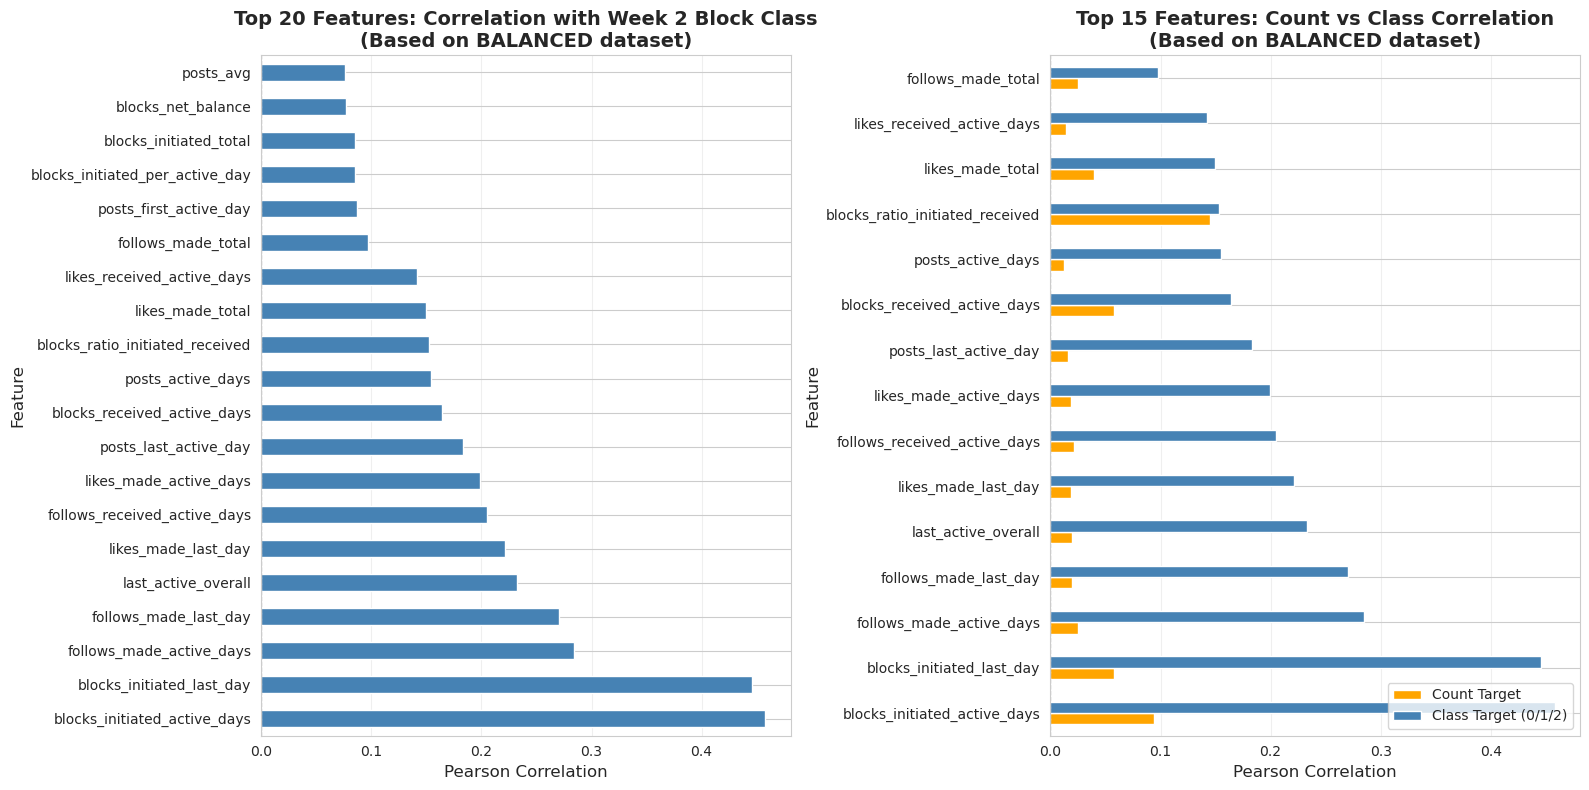

In [15]:
# Visualize feature correlations with bucketed class target (using BALANCED dataset)
import matplotlib.pyplot as plt
import seaborn as sns

# Top features
top_n = 20
top_features = comparison.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# 1. Bar plot: correlation with class
top_features['corr_with_class'].plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title(f'Top {top_n} Features: Correlation with Week 2 Block Class\n(Based on BALANCED dataset)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Pearson Correlation', fontsize=12)
axes[0].set_ylabel('Feature', fontsize=12)
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].grid(axis='x', alpha=0.3)

# 2. Comparison: count vs class correlation
top_features_plot = top_features.head(15)[['corr_with_count', 'corr_with_class']]
top_features_plot.plot(kind='barh', ax=axes[1], color=['orange', 'steelblue'])
axes[1].set_title('Top 15 Features: Count vs Class Correlation\n(Based on BALANCED dataset)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation', fontsize=12)
axes[1].set_ylabel('Feature', fontsize=12)
axes[1].legend(['Count Target', 'Class Target (0/1/2)'], loc='lower right')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()

# Save visualization
output_path = '../feature_correlation_problem.png'
plt.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Correlation plot saved to: {output_path}")

plt.show()


In [21]:
top_features_plot = top_features.head(15)[['corr_with_count', 'corr_with_class']]
print(top_features)

                                 corr_with_count  corr_with_class      diff
blocks_initiated_active_days            0.093662         0.457897  0.364235
blocks_initiated_last_day               0.058146         0.445578  0.387433
follows_made_active_days                0.025294         0.284534  0.259240
follows_made_last_day                   0.019480         0.270464  0.250984
last_active_overall                     0.019787         0.232748  0.212961
likes_made_last_day                     0.018639         0.221262  0.202623
follows_received_active_days            0.021461         0.204696  0.183235
likes_made_active_days                  0.018446         0.199077  0.180632
posts_last_active_day                   0.016062         0.183231  0.167169
blocks_received_active_days             0.057987         0.164089  0.106102
posts_active_days                       0.012682         0.154571  0.141889
blocks_ratio_initiated_received         0.144805         0.152917  0.008112
likes_made_t